# 31_04 — Evaluación predictiva · Metro Interstate (I-94) horario · volumen de tráfico · **barrido en $M$**

Paso **3b** del ciclo. Supone que `31_03_convergencia` dio veredicto OK **en
cada punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras
aquí no significan nada.

## Qué se reporta

- Predicción funcional a $h=1$ y su intervalo de credibilidad — se PERSISTEN, es lo que consume `31_05`
- **Bloque A** (MAE, RMSE, error máximo) sobre la ventana móvil
- **Bloque B** (Winkler, cobertura simultánea, cobertura puntual, MPIW) sobre la ventana móvil
- Muestra de predicciones: extractos regulares del test y las peores ventanas, con la curva anterior al lado
- Probabilidades posteriores de inclusión (PIP)
- Cuadro resumen: mínimo, máximo y promedio de cada métrica sobre la ventana
- Monitoreo univariado por componente FPCA
- **§10: evaluación puntual de los scores (coeficientes)** — banda de credibilidad de cada $\xi_k$, métricas de intervalo sobre ella, y dispersión $\hat\xi$ contra $\xi$

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.



## 1. Imports, `[CONFIG]` y artefactos

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

from model_psbp_fd.fit.convergencia_barrido import (
    cargar_artefactos, cargar_trazas, pip_punto,
)
from model_psbp_fd.fit.evaluacion_barrido import (
    METRICAS_A as _MA, METRICAS_B as _MB,
    cargar_representaciones, serie_origenes, predecir_barrido, guardar_bandas,
    tablas_ventana, apilar_tablas, verificar_relaciones_metricas,
    ganancias_por_ventana, tabla_ganadores_test, saltos_T0, peores_ventanas,
    resumen_metricas, resumen_barrido, monitoreo_scores, intervalos_scores,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_extractos_curvas,
    plot_ganador_ventana, plot_scores_banda, plot_scores_dispersion,
)
from model_psbp_fd.utils import get_project_root, experiment_id, normalizar_lista_M
from model_psbp_fd.utils.rutas import ruta_barrido_M

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Identidad de la corrida: mismos valores que 31_01 §1.1. El ID es
# real_<serie>_v<NN>_m<NN>; las funciones de fit/ lo arman con (BASE_LIB, ESCENARIO_ID, None).
BASENAME, SERIE_ID, VENTANA_ID = "real", "trafico_m10", 1   # ventana 1: 2015-07-01 .. 2018-09-30, 70/30 (31_01 §1.1)
M_FPCA_LIST = (10,)
DOMINIO      = "reales"
BASE_LIB     = f"{BASENAME}_{SERIE_ID}"
ESCENARIO_ID = f"v{VENTANA_ID:02d}"
REPLICA_ID   = None

# Propias de la evaluación. Las ventanas, el nivel y el objetivo se LEEN de
# eval_config.json (artefacto de 31_01): no se redeclaran aquí.
SALTAR_M_SIN_TRAZAS = True    # mirar el barrido mientras MATLAB va terminando
BURN_EVAL           = 1000    # iteraciones descartadas; None = el burn del .mat (500)
PESOS_TAU           = None    # cuadratura trapezoidal por defecto
METRICA_PEORES      = "rmse_f"   # cualquiera de las columnas de METRICAS_A / METRICAS_B
N_PEORES            = 5

# Predicción a h=1 (§3). S = (nsim - burn) x S_POR_ITER x n_cadenas draws por score;
# subirlos sólo reduce el error Monte Carlo de los cuantiles.
S_POR_ITER  = 1
S_FUNC      = 1000      # muestras funcionales tras adelgazar
BLOQUE_ORIG = 200       # orígenes por tramo al propagar a la curva (memoria; G = 288)
SEED_PRED   = 20260823
CADA        = 30        # un extracto de curva cada CADA períodos (§6)
CADA_BARRA  = 12        # un origen de cada CADA_BARRA lleva barra de IC (§10.3)

# §7: dispersión entre cadenas del PIP que se avisa.
SD_PIP_MAX = 0.15

# Las 10 métricas del marco teórico 02_02_03, en su orden. No se agregan otras.
METRICAS_A = [("1. MAE  (L^1)", "mae_f"), ("2. RMSE (L^2)", "rmse_f"),
              ("3. E_max promedio por curva", "linf_medio"),
              ("4. E_max peor de la ventana", "linf_max")]
METRICAS_B = [("5. MPIW", "mpiw"), ("6. PICP puntual", "picp"),
              ("7. PICPB curva completa", "picp_simultaneo"), ("8. Winkler", "winkler"),
              ("9. Winkler max promedio", "winkler_max_medio"),
              ("10. Winkler max peor ventana", "winkler_max_glob")]
assert METRICAS_A == _MA and METRICAS_B == _MB, "METRICAS_* difieren de fit.evaluacion_barrido."
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASE_LIB, ESCENARIO_ID, REPLICA_ID)
PATH_BARRIDO    = ruta_barrido_M(BASE_LIB, ESCENARIO_ID, REPLICA_ID, dominio=DOMINIO,
                                 project_root=PROJECT_ROOT)

print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
print(f"salidas cruzadas: {PATH_BARRIDO}")

EXPERIMENT_BASE : real_trafico_m10_v01
barrido en M    : [10]
salidas cruzadas: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_m10_v01_barrido_M


In [3]:
# EST[M]: estado de cada punto (cruza el contrato al cargar). DIS: diseño común.
EST, saltados = cargar_artefactos(BASE_LIB, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                                  PROJECT_ROOT, con_test=True, dominio=DOMINIO)
DIS = cargar_representaciones(EST)

T, T0, N_LAGS, NIVEL = DIS["T"], DIS["T0"], DIS["N_LAGS"], DIS["NIVEL"]
VENTANAS_W, W_REF    = DIS["VENTANAS_W"], DIS["W_REF"]
grilla, X_obs, X_suav = DIS["grilla"], DIS["X_obs"], DIS["X_suav"]

  M  comp  cadenas  covariables  seed_base
 10    10        1           10  41232

OK misma configuracion MCMC en todos los M: nsim/N/burn/cadenas = (2500, 30, 500, 1)


M=10  FPCA M=10 K=10  var. explicada=100.0000%  ·  curvas (1188, 24)

OK 1 puntos con el mismo diseno, objetivo, MCMC y simulacion.
T=1188 T0=831 n_lags=1   ventanas w=[20, 30, 40]   referencia w=30   nivel=0.95


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [4]:
M_OK = cargar_trazas(EST, SALTAR_M_SIN_TRAZAS, BURN_EVAL)     # los M efectivamente disponibles

OK M=10: 10 componente(s) x 1 cadena(s) · 1500 draws posteriores c/u -> 1500 por componente


## 3. Predicción a $h=1$ sobre la serie completa


In [5]:
ORIG = serie_origenes(DIS)
t_orig, n_orig, T0_orig, es_train = ORIG["t_orig"], ORIG["n_orig"], ORIG["T0_orig"], ORIG["es_train"]
X_obj_ev, X_obs_ev = ORIG["X_obj_ev"], ORIG["X_obs_ev"]

predecir_barrido(EST, M_OK, DIS, ORIG, S_POR_ITER, S_FUNC, BLOQUE_ORIG, SEED_PRED)

origenes evaluados: 1187  (train 830 · test 357)
SC_draws de TODO el barrido: 71 MB en float32


M=10: S=1500 extracciones por score · funcionales 1500 (1 de cada 1) · SC_draws 71 MB
       MISE del TRUNCAMIENTO FPCA (test) = 0.000000   <- distancia del objetivo a su propia proyeccion en M


### 3.1 Persistencia

La banda y la predicción puntual se guardan en `predict/` -no en `reports/`,
es un objeto de datos y no una salida de lectura- porque `31_05` las necesita
para calcular el Winkler del PSBPM-FD sobre su propia ventana móvil sin volver
a muestrear la predictiva completa.

In [6]:
guardar_bandas(EST, M_OK, DIS, ORIG)

[M=10] banda funcional -> banda_funcional_psbp.npz  (0.3 MB, (1187, 24))
Banda por CUANTILES de la predictiva muestral: no supone forma alguna.


## 4. Bloque A: error puntual sobre la ventana móvil

Las tres normas del MISMO error $e_t(\tau) = X_t(\tau) - \hat X_t(\tau)$:

| | qué estima | qué añade |
|---|---|---|
| **MAE** ($L^1$) | mediana condicional | robusta: un origen catastrófico no la mueve |
| **RMSE** ($L^2$) | media condicional | la que usa el PSBPM-FD y el resto del capítulo |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso | por curva, $\max_\tau \lvert e_t(\tau)\rvert$; sobre la ventana, el promedio de esos $w$ máximos |

Todo se calcula UNA vez por M en `tablas_fun` -la misma tabla que consume el
Bloque B de §5- y se dibuja aquí SOLO el Bloque A.

[ventana_movil_funcional[w=30]] inicio (1158 pasos)


  1/1158 ( 0.1%) t=0.0s eta=2.1s  t=16 [train] mise=0.5087


  57/1158 ( 4.9%) t=0.0s eta=0.3s  t=72 [train] mise=0.3942


  114/1158 ( 9.8%) t=0.0s eta=0.3s  t=129 [train] mise=0.2183


  171/1158 (14.8%) t=0.0s eta=0.2s  t=186 [train] mise=0.4108


...

  1083/1158 (93.5%) t=0.2s eta=0.0s  t=1098 [test] mise=0.3345


  1140/1158 (98.4%) t=0.3s eta=0.0s  t=1155 [test] mise=0.2698


  1158/1158 (100.0%) t=0.3s eta=0.0s  t=1173 [test] mise=0.3432


[ventana_movil_funcional[w=30]] listo: 1158 pasos en 0.3s  29 ventanas cruzan T0

OK relaciones entre metricas verificadas en 1 puntos x 3 anchos (L1<=L2<=Linf, PICPB<=PICP, W<=Wmax_medio<=Wmax_glob)


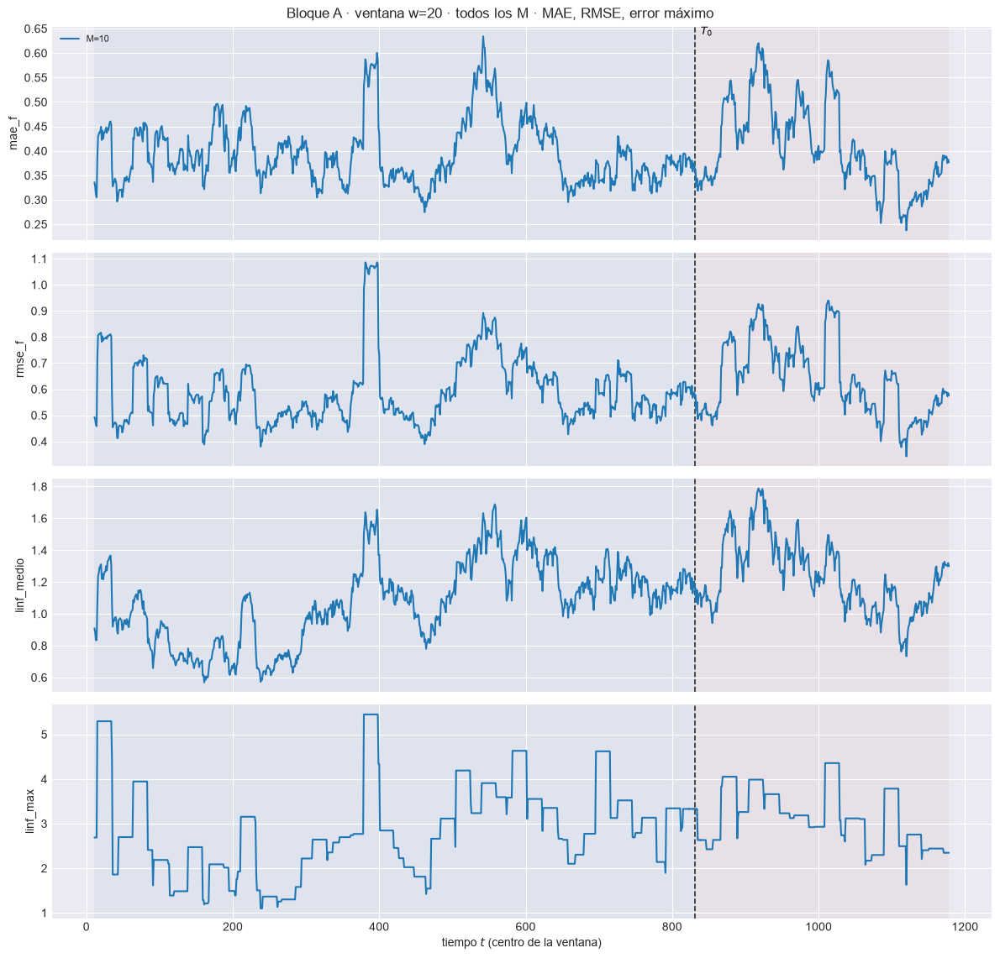

[plot_ventana_movil] inicio (4 pasos)


  1/4 (25.0%) t=0.0s eta=0.1s  mae_f: w=30 train=0.3885  w=30 test=0.4149


  2/4 (50.0%) t=0.0s eta=0.0s  rmse_f: w=30 train=0.5716  w=30 test=0.6285


  3/4 (75.0%) t=0.0s eta=0.0s  linf_medio: w=30 train=1.09  w=30 test=1.232


  4/4 (100.0%) t=0.1s eta=0.0s  linf_max: w=30 train=3.113  w=30 test=3.208


[plot_ventana_movil] listo: 4 pasos en 0.8s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_m10_v01_barrido_M\85_bloqueA_w30.png


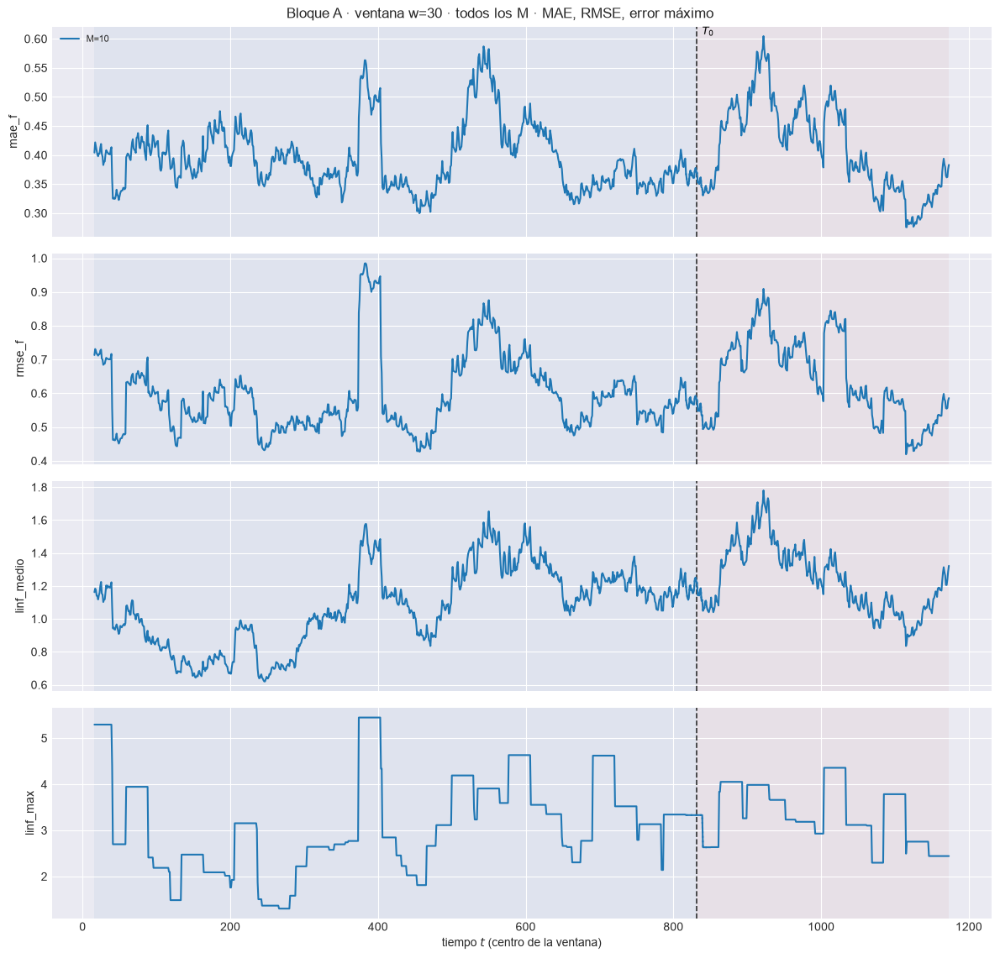

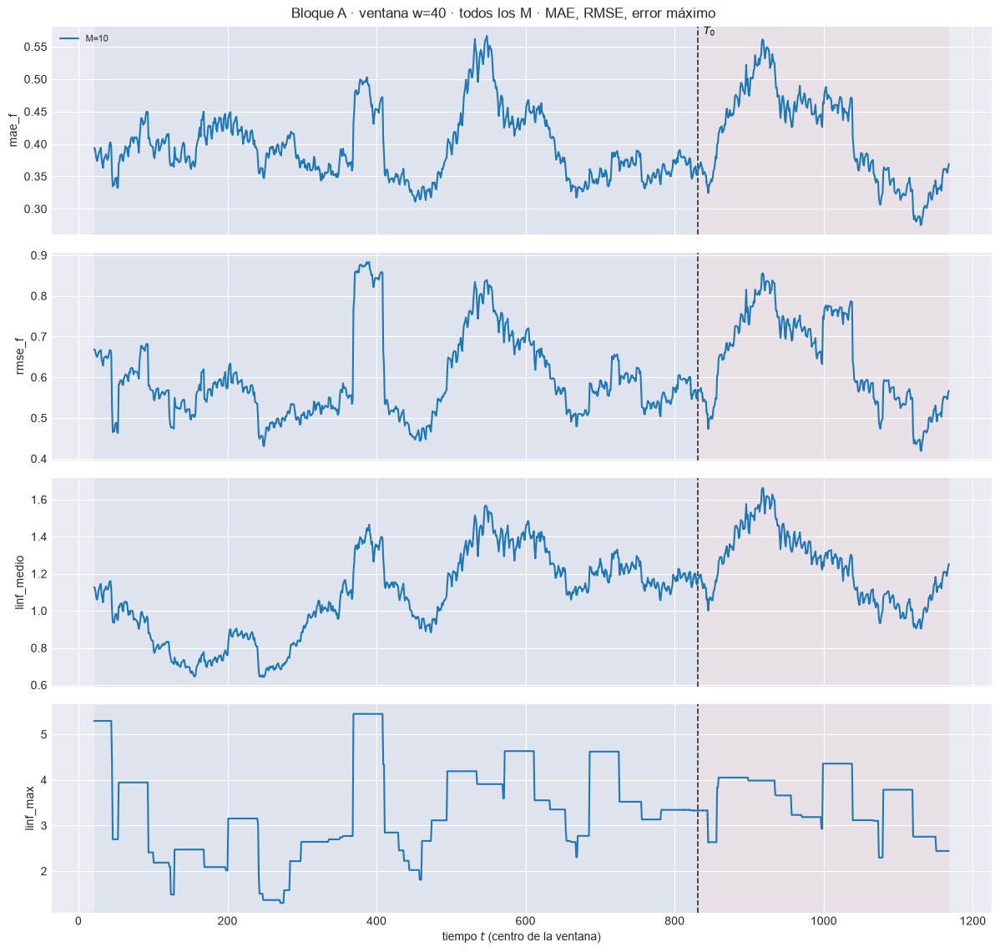

In [7]:
for M in M_OK:
    tablas_ventana(EST[M], DIS, ORIG, PESOS_TAU)
TABLAS_W = apilar_tablas(EST, M_OK, VENTANAS_W, METRICAS_A_COLS + METRICAS_B_COLS)
verificar_relaciones_metricas(EST, M_OK, VENTANAS_W)

# Una figura por ancho con los M superpuestos.
for w in VENTANAS_W:
    plot_ventana_movil(
        TABLAS_W[w], T0, METRICAS_A_COLS, columna_grupo="punto",
        title=f"Bloque A · ventana w={w} · todos los M · MAE, RMSE, error máximo",
        save_path=str(PATH_BARRIDO / f"85_bloqueA_w{w}.png"), verbose=(w == W_REF))
    plt.show()

### 4.1 ¿Qué $M$ gana en cada ventana, y en cada ancho?


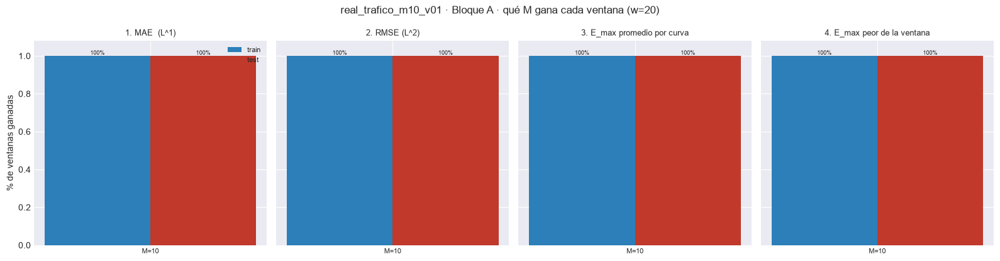

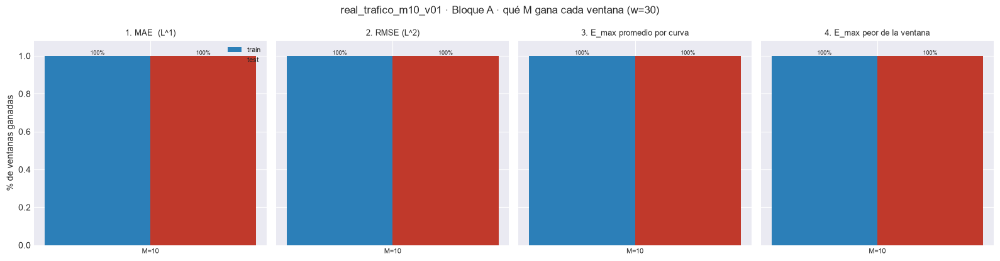

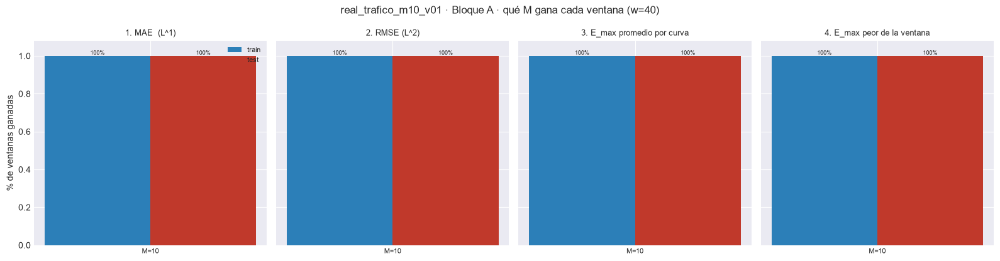

In [8]:
GANA_A = ganancias_por_ventana(EST, M_OK, VENTANAS_W, METRICAS_A, NIVEL)
GANA_B = ganancias_por_ventana(EST, M_OK, VENTANAS_W, METRICAS_B, NIVEL)
GANA_A.to_csv(PATH_BARRIDO / "84_ganador_por_ventana.csv", index=False)
GANA_B.to_csv(PATH_BARRIDO / "87_ganador_bloqueB.csv", index=False)

for w in VENTANAS_W:
    plot_ganador_ventana(GANA_A, METRICAS_A, w, M_OK,
                         f"{EXPERIMENT_BASE} · Bloque A · qué M gana cada ventana (w={w})",
                         PATH_BARRIDO / f"84_ganador_por_ventana_w{w}.png")
    plt.show()

display(tabla_ganadores_test(GANA_A).style.format("{:.1%}")
        .set_caption("Bloque A · % de ventanas TEST ganadas por M (84_ganador_por_ventana.csv)"))

# Salto del MISE en T0, sin las ventanas que lo cruzan.
display(saltos_T0(EST, M_OK, VENTANAS_W).set_index(["M", "w"]).style
        .format({"mise_train": "{:.6f}", "mise_test": "{:.6f}", "salto": "{:.2f}x"})
        .set_caption("MISE train / test y salto en T0"))

## 5. Bloque B: intervalos de predicción, en una sola vista

Cuatro cifras del intervalo, ninguna "primaria" en esta vista -el Winkler es
la única regla de puntuación propia y por eso es la que ordena modelos cuando
hace falta ordenar, pero aquí se muestran las cuatro juntas-:

| | qué es | de qué es |
|---|---|---|
| **Winkler** | interval score | penaliza ancho Y cobertura a la vez |
| **Cobertura simultánea** | de $w$ curvas, cuántas quedan COMPLETAS dentro de su banda (1/0 por curva) | fracción de CURVAS |
| **Cobertura puntual (PICP)** | de una curva, qué fracción de $\tau$ cae dentro | promedio de esa fracción sobre la ventana |
| **MPIW** | ancho medio de la banda | — |

La cobertura simultánea es SIEMPRE $\le$ la puntual: basta un $\tau$ fuera
para que la curva entera cuente como no cubierta.

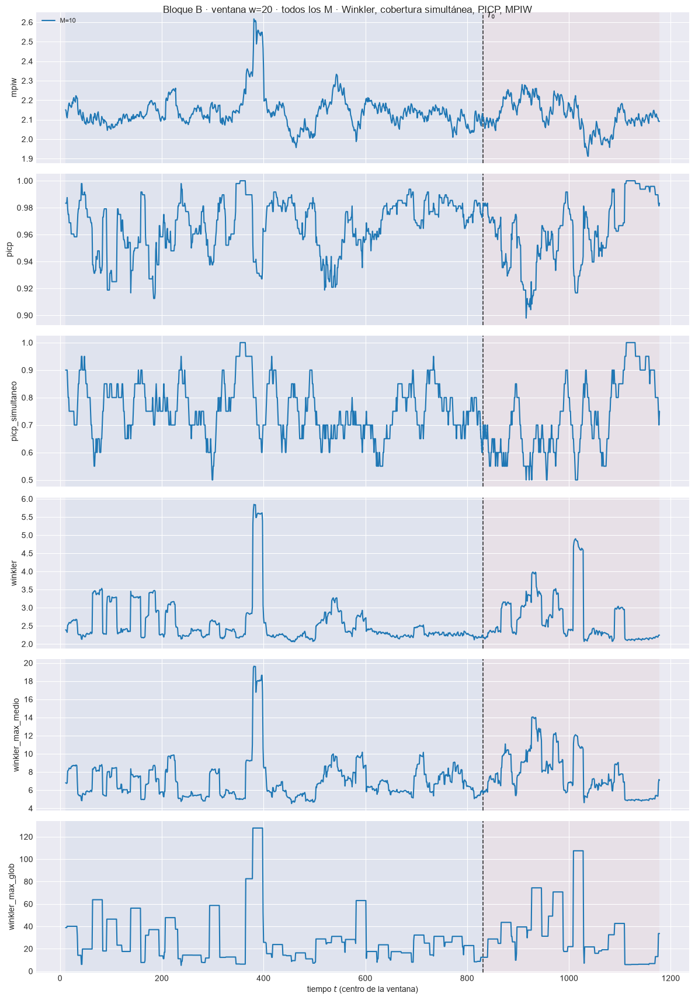

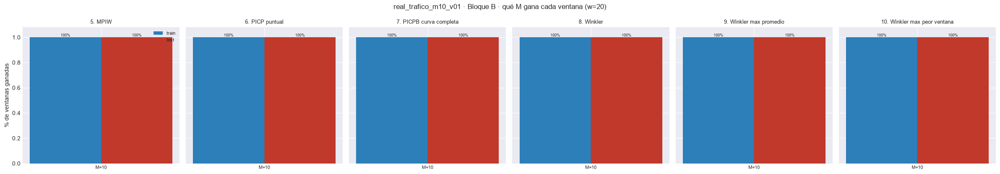

[plot_ventana_movil] inicio (6 pasos)


  1/6 (16.7%) t=0.0s eta=0.1s  mpiw: w=30 train=2.13  w=30 test=2.123


  2/6 (33.3%) t=0.0s eta=0.0s  picp: w=30 train=0.9667  w=30 test=0.9583


  3/6 (50.0%) t=0.0s eta=0.0s  picp_simultaneo: w=30 train=0.7667  w=30 test=0.7


  4/6 (66.7%) t=0.0s eta=0.0s  winkler: w=30 train=2.373  w=30 test=2.699


  5/6 (83.3%) t=0.1s eta=0.0s  winkler_max_medio: w=30 train=6.988  w=30 test=7.676


  6/6 (100.0%) t=0.1s eta=0.0s  winkler_max_glob: w=30 train=31.05  w=30 test=39.47


[plot_ventana_movil] listo: 6 pasos en 1.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_m10_v01_barrido_M\86_bloqueB_w30.png


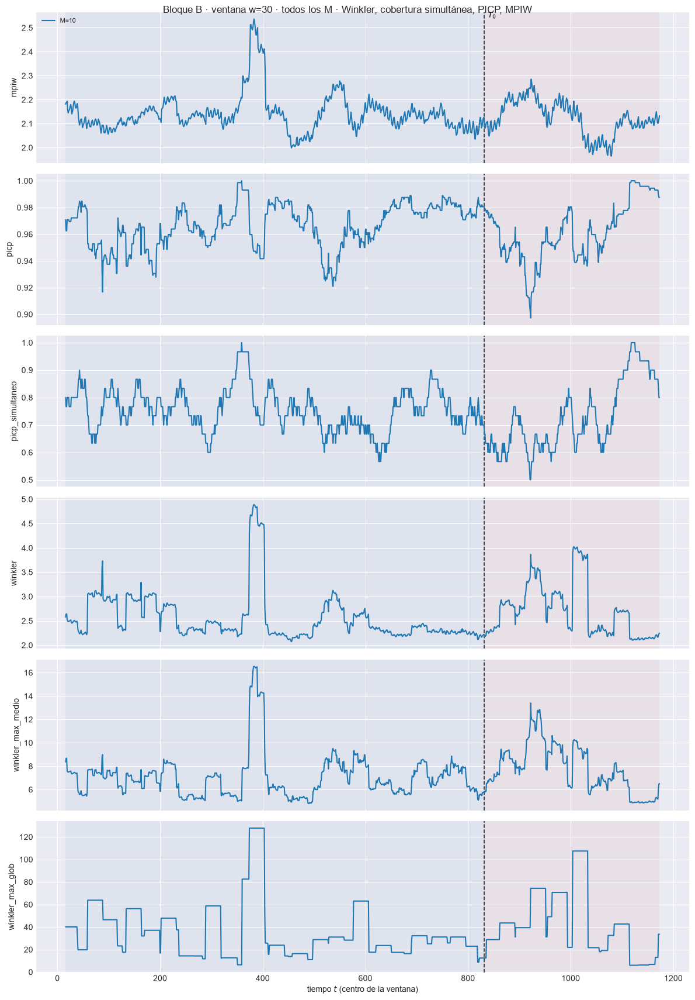

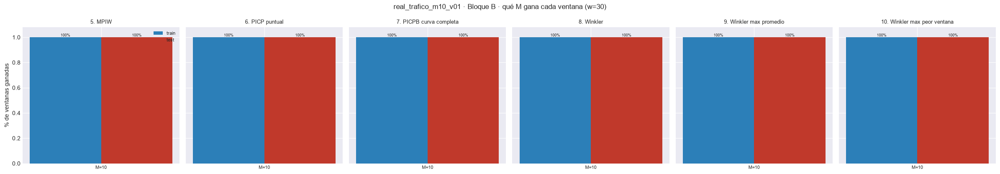

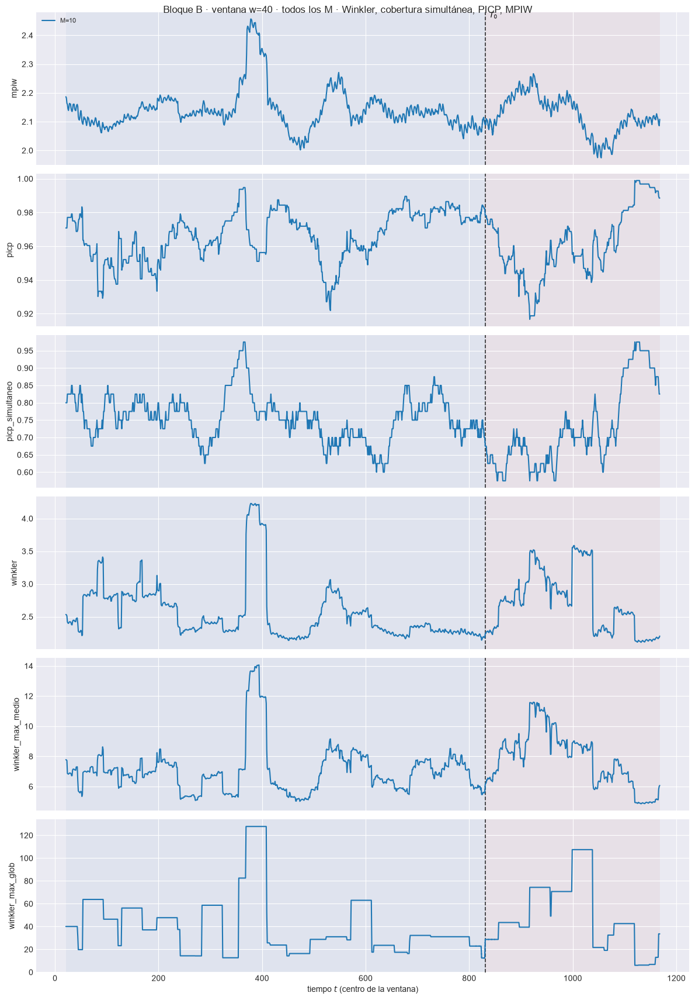

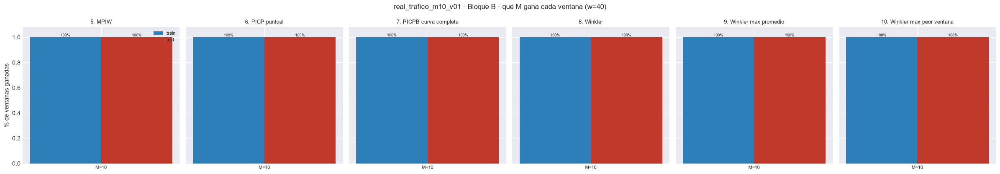

In [9]:
for w in VENTANAS_W:
    plot_ventana_movil(
        TABLAS_W[w], T0, METRICAS_B_COLS, columna_grupo="punto",
        title=f"Bloque B · ventana w={w} · todos los M · Winkler, cobertura simultánea, PICP, MPIW",
        save_path=str(PATH_BARRIDO / f"86_bloqueB_w{w}.png"), verbose=(w == W_REF))
    plt.show()
    # En picp el objetivo es el NOMINAL, no el mínimo.
    plot_ganador_ventana(GANA_B, METRICAS_B, w, M_OK,
                         f"{EXPERIMENT_BASE} · Bloque B · qué M gana cada ventana (w={w})",
                         PATH_BARRIDO / f"87_ganador_bloqueB_w{w}.png")
    plt.show()

display(tabla_ganadores_test(GANA_B).style.format("{:.1%}")
        .set_caption("Bloque B · % de ventanas TEST ganadas por M (87_ganador_bloqueB.csv)"))

## 6. Muestra de predicciones

Dos vistas: un extracto regular del bloque de **prueba** (para no mezclar con
in-sample), y las ventanas con **peor** valor de `METRICA_PEORES` ([CONFIG]).
En la segunda se agrega la curva **anterior** ($t-1$, gris punteada): es el
primer diagnóstico de POR QUÉ el modelo se equivocó -¿la curva de partida ya
era atípica?-.

[plot_extractos_curvas] inicio (12 pasos)


  1/12 ( 8.3%) t=0.0s eta=0.1s  t=832 [test] cob=1.000 rmse=0.3976


  2/12 (16.7%) t=0.0s eta=0.1s  t=862 [test] cob=0.917 rmse=0.3028


  3/12 (25.0%) t=0.0s eta=0.1s  t=892 [test] cob=1.000 rmse=0.2013


  4/12 (33.3%) t=0.0s eta=0.1s  t=922 [test] cob=1.000 rmse=1.139


...

  9/12 (75.0%) t=0.1s eta=0.0s  t=1072 [test] cob=0.958 rmse=0.2366


  10/12 (83.3%) t=0.1s eta=0.0s  t=1102 [test] cob=1.000 rmse=0.2543


  11/12 (91.7%) t=0.1s eta=0.0s  t=1132 [test] cob=1.000 rmse=0.7964


  12/12 (100.0%) t=0.1s eta=0.0s  t=1162 [test] cob=1.000 rmse=0.3084


[plot_extractos_curvas] listo: 12 pasos en 2.0s  cob media train=nan test=0.983 (nominal 0.95)


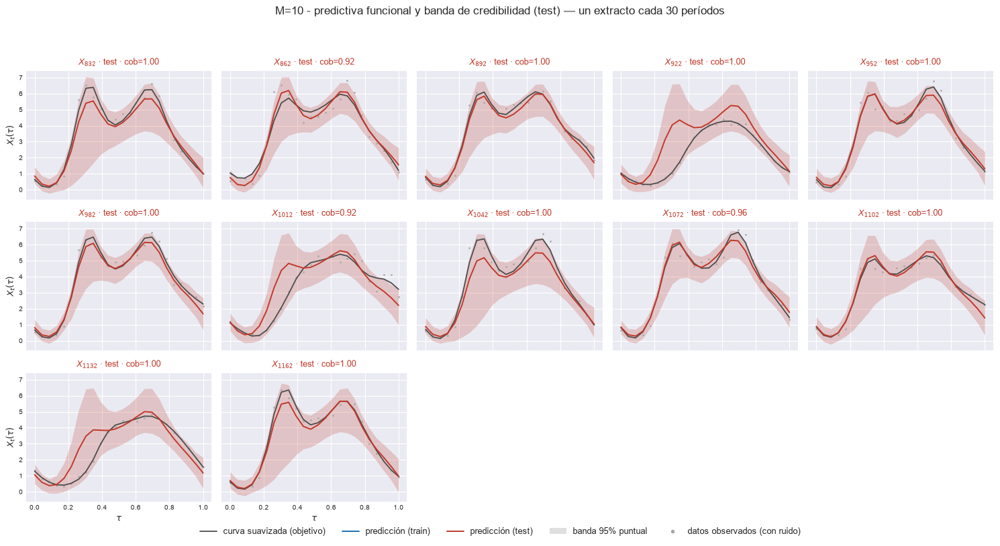

In [10]:
# Extractos regulares, SOLO del bloque de prueba.
mask_test = ~es_train
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_obj_ev[mask_test], e["X_pred"][mask_test], e["li_f"][mask_test], e["ls_f"][mask_test],
        grilla, T0, t=t_orig[mask_test], cada=CADA, n_col=5, nivel=NIVEL,
        etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[mask_test],
        title=f"M={M} - predictiva funcional y banda de credibilidad (test)",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas_test.png"), verbose=True)
    plt.show()

[plot_extractos_curvas] inicio (7 pasos)


  1/7 (14.3%) t=0.0s eta=0.0s  t=828 [train] cob=1.000 rmse=0.182


  2/7 (28.6%) t=0.0s eta=0.0s  t=829 [train] cob=0.958 rmse=0.3185


  3/7 (42.9%) t=0.0s eta=0.0s  t=830 [train] cob=0.958 rmse=0.7489


  4/7 (57.1%) t=0.0s eta=0.0s  t=831 [train] cob=1.000 rmse=0.4631


  5/7 (71.4%) t=0.0s eta=0.0s  t=832 [test] cob=1.000 rmse=0.3976


  6/7 (85.7%) t=0.0s eta=0.0s  t=833 [test] cob=1.000 rmse=0.2834


  7/7 (100.0%) t=0.0s eta=0.0s  t=834 [test] cob=1.000 rmse=0.2622


[plot_extractos_curvas] listo: 7 pasos en 1.4s  cob media train=0.979 test=1.000 (nominal 0.95)


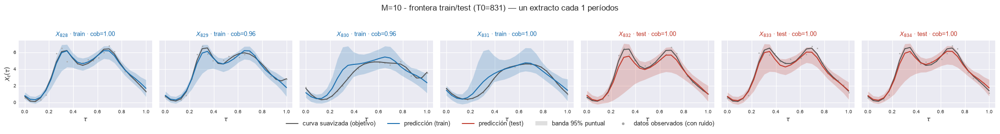

In [11]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_obj_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel], grilla, T0,
        t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"), verbose=True)
    plt.show()

[M=10] peores 5 ventanas por rmse_f (w=30, test, sin cruzar T0)
    t=[908, 937]  rmse_f=0.909301


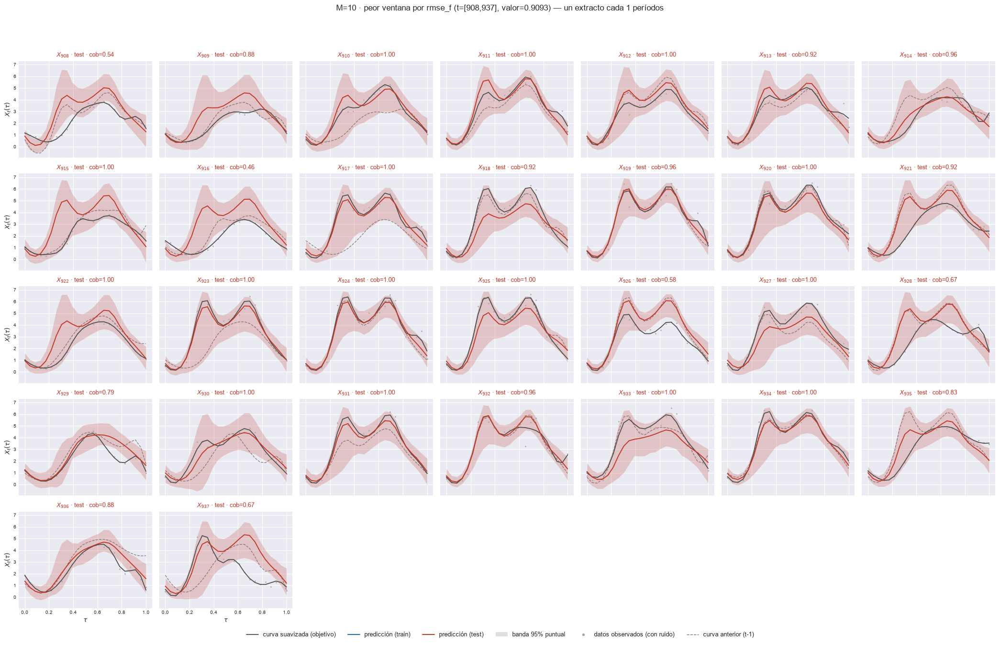

    t=[914, 943]  rmse_f=0.883516


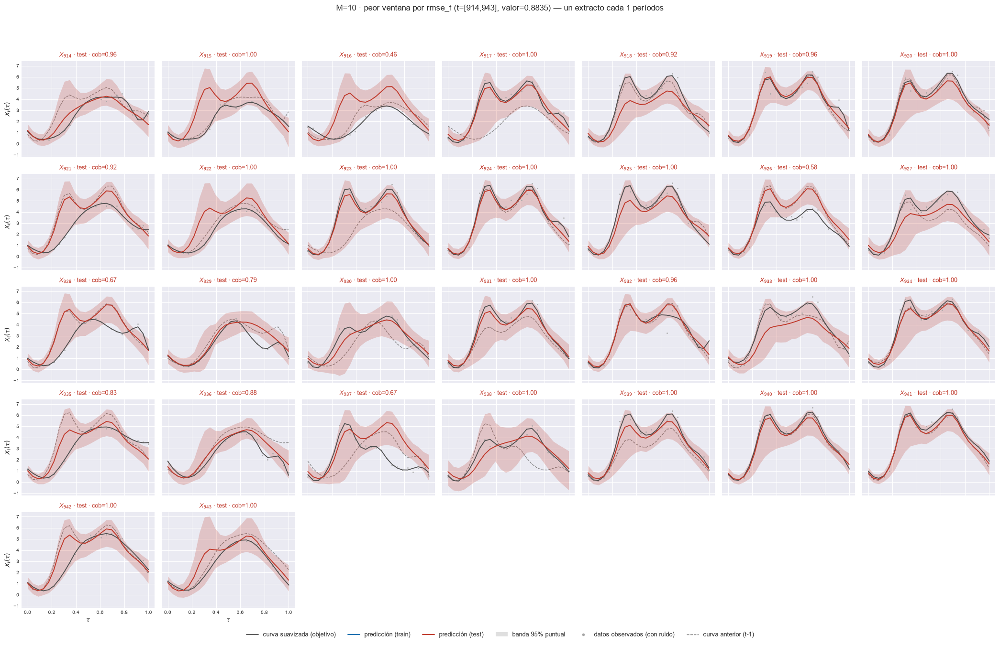

    t=[909, 938]  rmse_f=0.883162


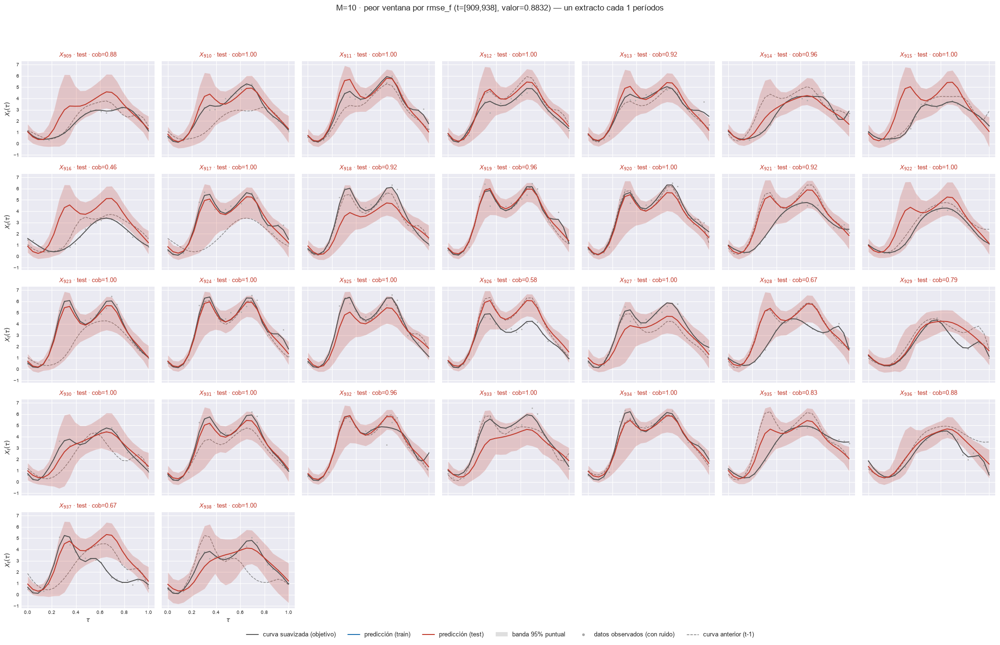

    t=[915, 944]  rmse_f=0.881109


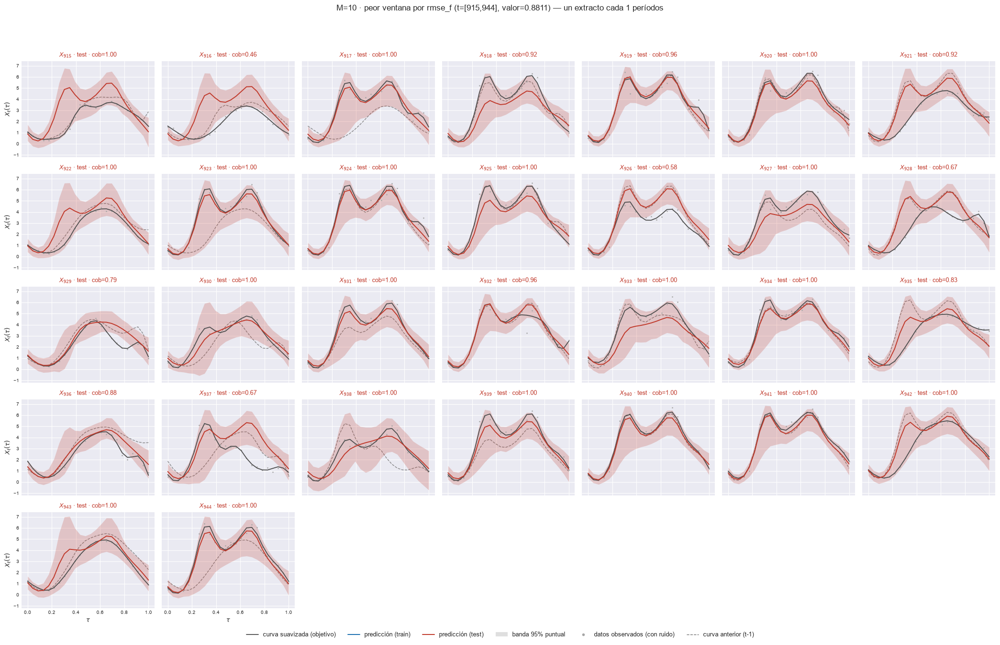

    t=[900, 929]  rmse_f=0.879842


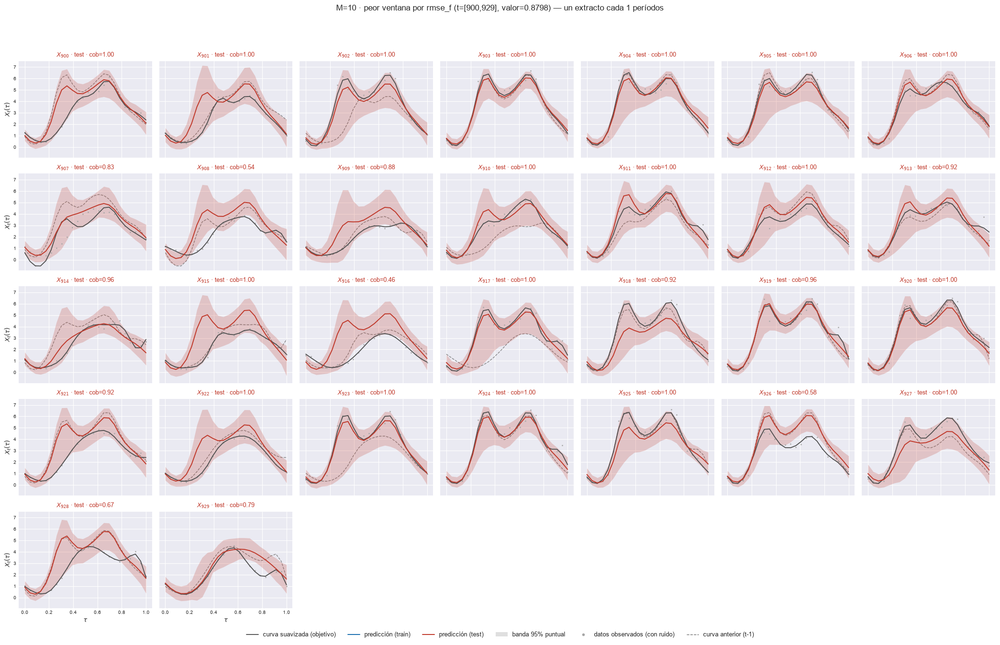

In [12]:
# Peores ventanas de test, con la curva anterior (t-1) al lado.
X_prev_full = np.full_like(X_obj_ev, np.nan)
X_prev_full[1:] = X_obj_ev[:-1]

for M in M_OK:
    e = EST[M]
    peores = peores_ventanas(e, W_REF, METRICA_PEORES, N_PEORES)
    print(f"[M={M}] peores {len(peores)} ventanas por {METRICA_PEORES} (w={W_REF}, test, sin cruzar T0)")
    for _, row in peores.iterrows():
        ini, fin = int(row["t_ini"]), int(row["t_fin"])
        print(f"    t=[{ini}, {fin}]  {METRICA_PEORES}={row[METRICA_PEORES]:.6f}")
        sel = np.where((t_orig >= ini) & (t_orig <= fin))[0]
        if sel.size == 0:
            continue
        plot_extractos_curvas(
            X_obj_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel], grilla, T0,
            t=t_orig[sel], cada=1, n_col=min(len(sel), 7), nivel=NIVEL,
            etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[sel],
            X_prev=X_prev_full[sel],
            title=f"M={M} · peor ventana por {METRICA_PEORES} (t=[{ini},{fin}], "
                  f"valor={row[METRICA_PEORES]:.4f})",
            save_path=str(e["paths"]["out_report"] / f"56b_peor_ventana_{METRICA_PEORES}_t{ini}.png"),
            verbose=False)
        plt.show()

## 7. Probabilidades posteriores de inclusión (PIP)

Qué covariables (rezago 1 de cada componente, propia y cruzadas) selecciona el modelo en cada componente. Con datos reales no hay estructura verdadera contra la cual contrastar: se reporta el PIP global y su dispersión entre cadenas.


In [13]:
for M in M_OK:
    pip_df = pip_punto(EST[M], SD_PIP_MAX)
    display(pip_df.style
        .background_gradient(subset=[c for c in pip_df.columns if not c.endswith("_sd")],
                             cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} · P(gamma_j = 1 | datos), inclusión global, media entre cadenas ± sd"))

[matriz_pip] inicio (10 pasos)


  1/10 (10.0%) t=0.0s eta=0.0s  FPC 1: 1 cadenas, 10 variables, PIP en [0.058, 1.000]


  2/10 (20.0%) t=0.0s eta=0.0s  FPC 2: 1 cadenas, 10 variables, PIP en [0.163, 1.000]


  3/10 (30.0%) t=0.0s eta=0.0s  FPC 3: 1 cadenas, 10 variables, PIP en [0.103, 1.000]


  4/10 (40.0%) t=0.0s eta=0.0s  FPC 4: 1 cadenas, 10 variables, PIP en [0.315, 1.000]


...

  9/10 (90.0%) t=0.0s eta=0.0s  FPC 9: 1 cadenas, 10 variables, PIP en [0.308, 1.000]


  10/10 (100.0%) t=0.0s eta=0.0s  FPC 10: 1 cadenas, 10 variables, PIP en [0.139, 1.000]


[matriz_pip] listo: 10 pasos en 0.0s  tabla 10x20


[M=10] dispersion maxima entre cadenas: 0.000   OK las cadenas coinciden


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd,FPC 4,FPC 4_sd,FPC 5,FPC 5_sd,FPC 6,FPC 6_sd,FPC 7,FPC 7_sd,FPC 8,FPC 8_sd,FPC 9,FPC 9_sd,FPC 10,FPC 10_sd
variable,,,,,,,,,,,,,,,,,,,,
fpc_1_lag1,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.167,0.000,1.000,0.000,1.000,0.000,0.308,0.000,0.187,0.000
fpc_2_lag1,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.359,0.000,0.115,0.000,0.087,0.000,0.042,0.000,1.000,0.000,0.172,0.000
fpc_3_lag1,1.000,0.000,0.200,0.000,1.000,0.000,0.841,0.000,1.000,0.000,0.327,0.000,0.129,0.000,0.060,0.000,1.000,0.000,1.000,0.000
fpc_4_lag1,1.000,0.000,1.000,0.000,0.134,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.095,0.000,0.045,0.000,0.912,0.000,0.213,0.000
fpc_5_lag1,1.000,0.000,0.205,0.000,0.333,0.000,0.339,0.000,1.000,0.000,0.165,0.000,0.108,0.000,0.065,0.000,0.419,0.000,0.179,0.000
fpc_6_lag1,0.378,0.000,0.205,0.000,0.103,0.000,0.545,0.000,0.321,0.000,1.000,0.000,0.092,0.000,0.037,0.000,0.318,0.000,0.166,0.000
fpc_7_lag1,0.077,0.000,0.178,0.000,0.105,0.000,0.315,0.000,0.776,0.000,0.118,0.000,1.000,0.000,0.043,0.000,0.902,0.000,0.171,0.000
fpc_8_lag1,0.076,0.000,1.000,0.000,0.123,0.000,0.504,0.000,0.429,0.000,0.471,0.000,0.129,0.000,1.000,0.000,0.377,0.000,0.139,0.000
fpc_9_lag1,0.058,0.000,0.284,0.000,0.109,0.000,0.339,0.000,0.320,0.000,0.119,0.000,0.151,0.000,0.101,0.000,1.000,0.000,0.150,0.000


## 8. Cuadro resumen: mínimo, máximo y promedio

La ventana móvil genera una SERIE por métrica, no una cifra. Esta tabla es la
lectura resumida de esa serie: mínimo, máximo y promedio, por bloque
train/test, excluyendo las ventanas que cruzan $T_0$ -su cifra mezcla dentro y
fuera de muestra-. Cubre las 7 métricas de los Bloques A y B; ninguna se
destaca sobre las demás.

In [14]:
# Los dos objetivos en la misma tabla, con la columna que declara cuál.
for M in M_OK:
    resumen = resumen_metricas(EST[M], M, DIS, ORIG)
    display(resumen.style.format({"minimo": "{:.6f}", "maximo": "{:.6f}", "promedio": "{:.6f}"})
            .set_caption(f"M={M} · mínimo / máximo / promedio por ventana "
                         f"(w={W_REF}, sin cruzar T0) · nivel funcional"))

resumen_bar = resumen_barrido(EST, M_OK, PATH_BARRIDO)
# Vista rápida: un solo objetivo (el primario del Bloque A); el CSV tiene los dos.
display(resumen_bar[(resumen_bar.bloque == "test") & (resumen_bar.objetivo == "curva_suavizada")]
        .pivot(index="metrica", columns="M", values="promedio").style.format("{:.6f}")
        .set_caption("Promedio en TEST contra M, objetivo=curva_suavizada (89_resumen_por_M.csv)"))

[M=10] curva_suavizada      PICP puntual test = 0.9613 (nominal 0.95)  ·  PICP simultaneo test = 0.7308
[M=10] representacion_fpca  PICP puntual test = 0.9613 (nominal 0.95)  ·  PICP simultaneo test = 0.7308


M,10
metrica,
1. MAE (L^1),0.413007
10. Winkler max peor ventana,43.392017
2. RMSE (L^2),0.646283
3. E_max promedio por curva,1.241151
4. E_max peor de la ventana,3.346644
5. MPIW,2.124114
6. PICP puntual,0.961310
7. PICPB curva completa,0.730793
8. Winkler,2.733897


## 9. Monitoreo univariado por componente FPCA

Cada componente FPCA retenida se predice de manera univariada dentro del
modelo -es una mezcla por componente-, así que aquí se mira su MAE, RMSE y
MISE (= RMSE² del score, el análogo puntual del MISE funcional) por separado,
sobre la ventana móvil. Con $M=1$ hay una sola línea por panel; con $M=k$ hay
$k$ líneas, una por componente. **Solo monitoreo**: ninguna de las tres es
primaria.

[ventana_movil_scores[FPC 1, w=30]] inicio (1158 pasos)


  1/1158 ( 0.1%) t=0.0s eta=1.4s  t=16 [train] rmse=0.6543


  57/1158 ( 4.9%) t=0.0s eta=0.2s  t=72 [train] rmse=0.5449


  114/1158 ( 9.8%) t=0.0s eta=0.2s  t=129 [train] rmse=0.3733


  171/1158 (14.8%) t=0.0s eta=0.2s  t=186 [train] rmse=0.5327


...

  1026/1158 (88.6%) t=0.2s eta=0.0s  t=1041 [test] rmse=0.01767

  1083/1158 (93.5%) t=0.2s eta=0.0s  t=1098 [test] rmse=0.02597


  1140/1158 (98.4%) t=0.2s eta=0.0s  t=1155 [test] rmse=0.01937


  1158/1158 (100.0%) t=0.2s eta=0.0s  t=1173 [test] rmse=0.02184


[ventana_movil_scores[FPC 10, w=30]] listo: 1158 pasos en 0.2s  29 ventanas cruzan T0


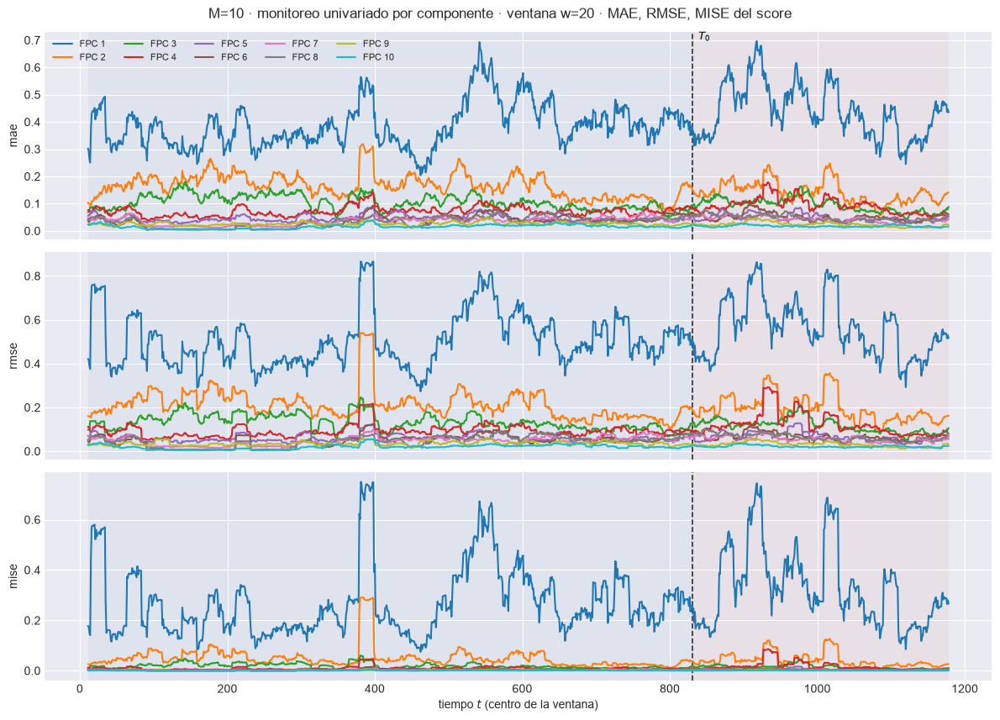

[plot_ventana_movil] inicio (3 pasos)


  1/3 (33.3%) t=0.1s eta=0.1s  mae: w=30 train=0.047  w=30 test=0.05369


  2/3 (66.7%) t=0.1s eta=0.1s  rmse: w=30 train=0.06269  w=30 test=0.07115


  3/3 (100.0%) t=0.2s eta=0.0s  mise: w=30 train=0.003929  w=30 test=0.005062


[plot_ventana_movil] listo: 3 pasos en 1.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_m10_v01_m10\91_ventana_univariado_w30.png


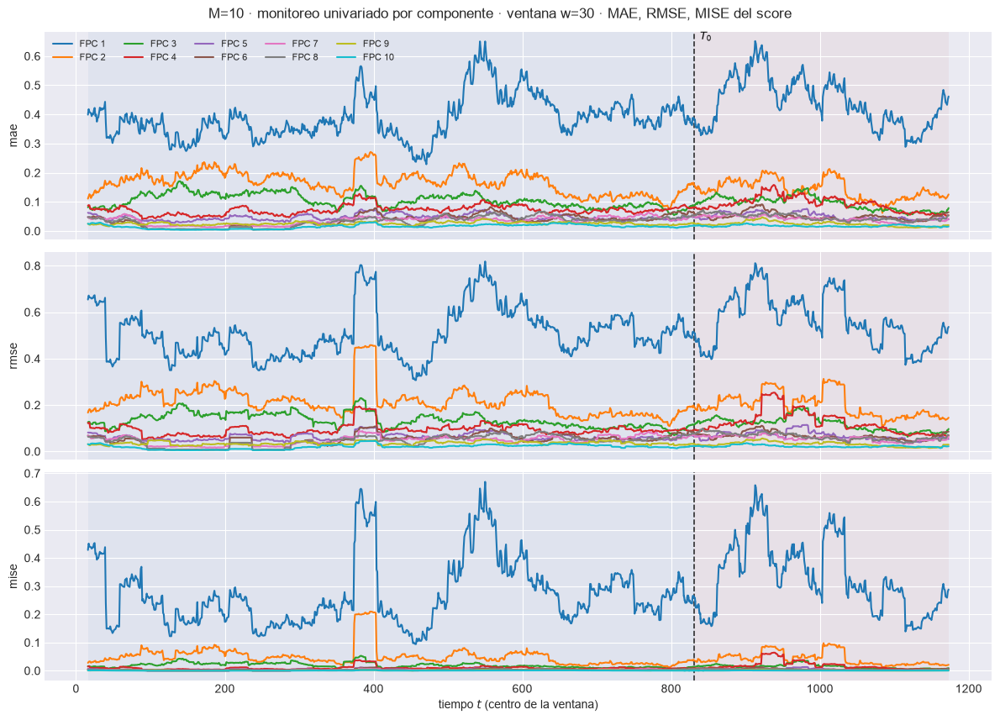

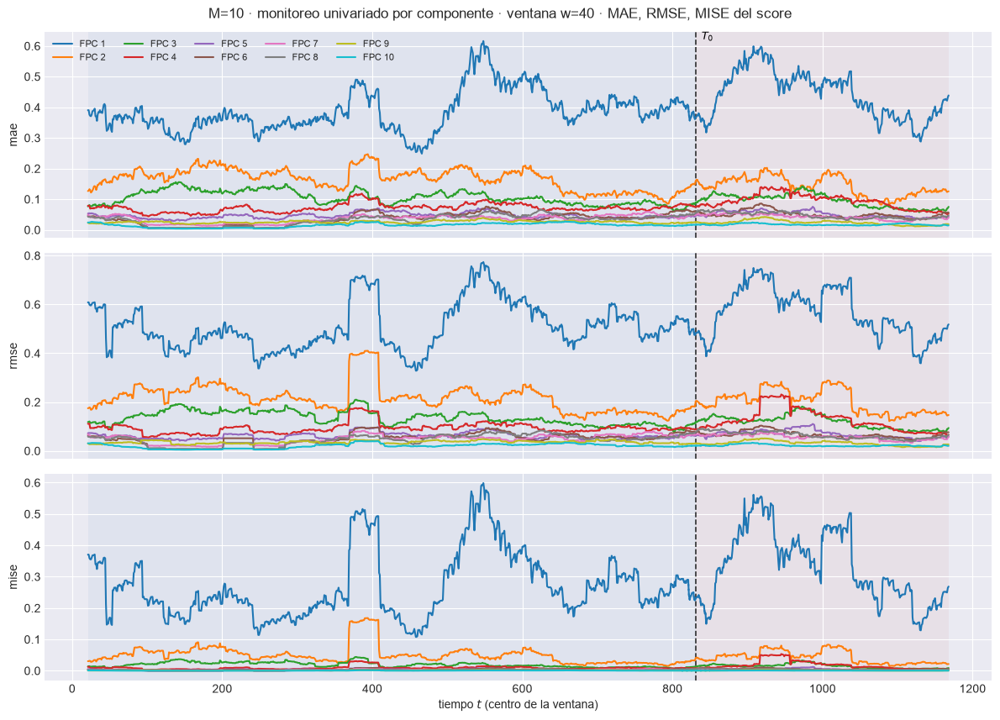

In [15]:
for M in M_OK:
    e = EST[M]
    monitoreo_scores(e, DIS, ORIG)
    for w in VENTANAS_W:
        tsc = e["tablas_score"][w].copy()
        tsc["mise"] = tsc["rmse"] ** 2      # MSE del score: análogo puntual del MISE
        plot_ventana_movil(
            tsc, T0, ["mae", "rmse", "mise"], columna_grupo="componente",
            title=f"M={M} · monitoreo univariado por componente · ventana w={w} · MAE, RMSE, MISE del score",
            save_path=str(e["paths"]["out_report"] / f"91_ventana_univariado_w{w}.png"),
            verbose=(w == W_REF))
        plt.show()

## 10. Evaluación puntual de los scores (coeficientes FPCA)

Las secciones anteriores miran la **curva**, que es el producto final. Ésta
mira el objeto que el muestreador predice de verdad: el score $\xi_{t,k}$ de
cada componente. La curva sale de propagarlos, así que un problema de
calibración que aquí se vea localizado en una componente queda, allá,
promediado con las demás y es mucho más difícil de atribuir.

| | qué muestra |
|---|---|
| **§10.1** | el intervalo de credibilidad de cada $\xi_k$ a lo largo del tiempo, con $\xi$ observado encima |
| **§10.2** | las métricas de ese intervalo: PICP, MPIW, Winkler, ACE — globales por bloque y sobre la ventana móvil, un panel por ancho |
| **§10.3** | dispersión $\hat\xi$ contra $\xi$ con la diagonal, componente a componente |

La banda es `li_s`/`ls_s`, los cuantiles muestrales de la predictiva por score
que §3 ya calculó: es **la misma** de la que sale la banda funcional, antes de
propagarla. No se vuelve a muestrear nada.


### 10.1 Cómo se mueve el intervalo de credibilidad de cada score

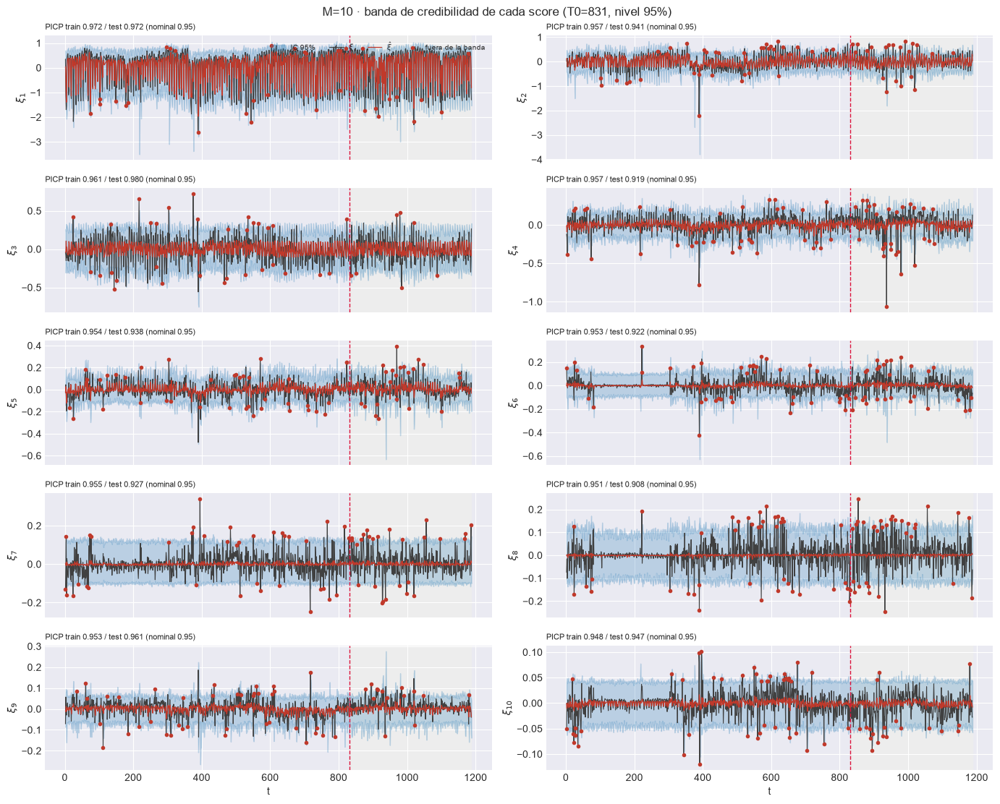

In [16]:
for M in M_OK:
    plot_scores_banda(EST[M], ORIG, DIS, M,
                      save_path=EST[M]["paths"]["out_report"] / "92_scores_banda_credibilidad.png")
    plt.show()

### 10.2 Métricas de intervalo sobre los scores

Las mismas cuatro cifras del Bloque B, pero por componente y en la escala del
score: **PICP** (fracción de orígenes cubiertos), **MPIW** (ancho medio),
**Winkler** (regla de puntuación que penaliza ancho y fallo a la vez) y
**ACE** = PICP − nominal, que es el signo de la miscalibración: negativo es
subcobertura.

Primero la lectura global por bloque; después la evolución sobre la ventana
móvil, **un panel por ancho**, con el mismo criterio de §4 y §5.


OK ninguna componente se aleja mas de 0.1 del nominal en test.


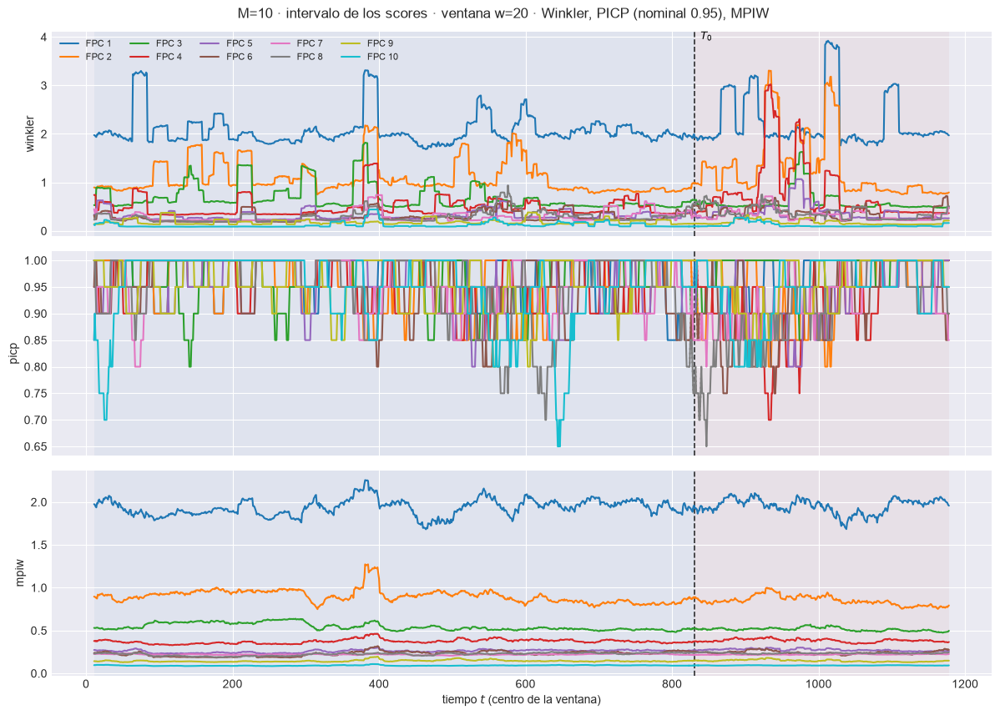

[plot_ventana_movil] inicio (3 pasos)


  1/3 (33.3%) t=0.1s eta=0.1s  winkler: w=30 train=0.3345  w=30 test=0.3885


  2/3 (66.7%) t=0.1s eta=0.1s  picp: w=30 train=0.9667  w=30 test=0.9667


  3/3 (100.0%) t=0.2s eta=0.0s  mpiw: w=30 train=0.2471  w=30 test=0.2613


[plot_ventana_movil] listo: 3 pasos en 1.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_trafico_m10_v01_m10\93_ventana_scores_intervalo_w30.png


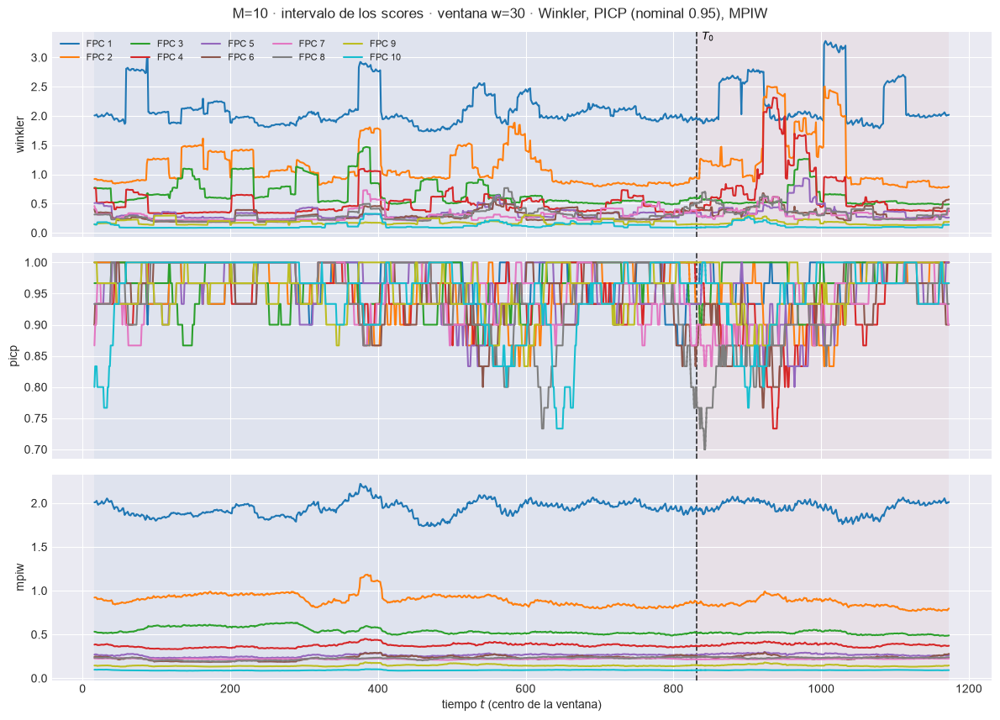

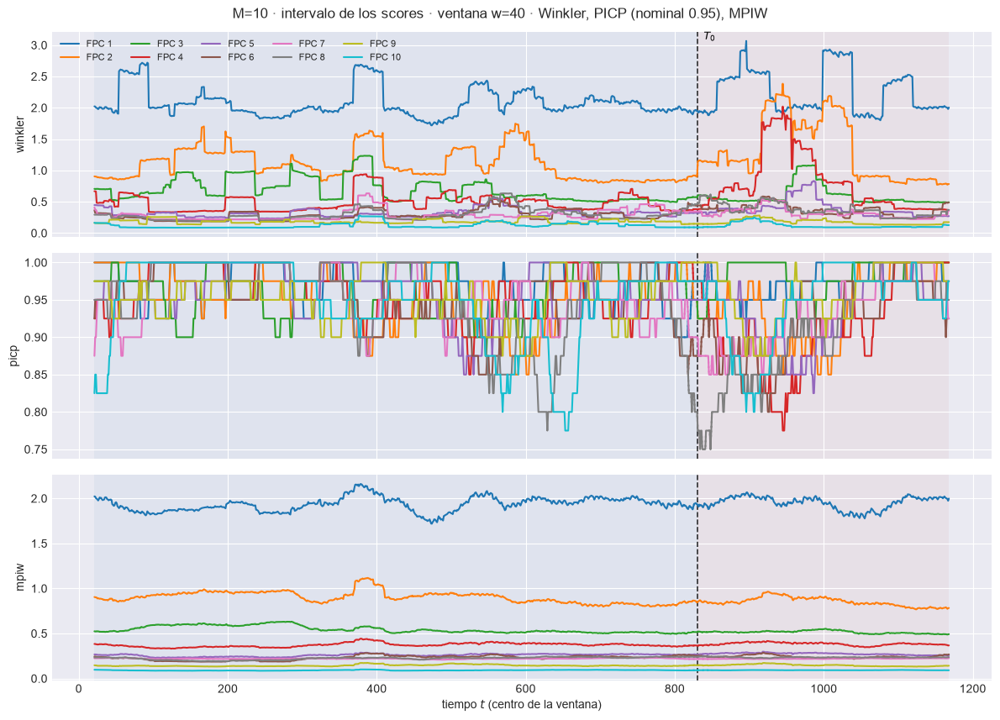

In [17]:
INT_SCORES = intervalos_scores(EST, M_OK, DIS, ORIG, PATH_BARRIDO)
display(INT_SCORES.set_index(["M", "componente", "bloque"]).style
        .format({"picp": "{:.4f}", "ace": "{:+.4f}", "mpiw": "{:.4f}", "winkler": "{:.4f}",
                 "sd_banda": "{:.4f}", "rmse": "{:.4f}", "mpiw_sobre_rmse": "{:.2f}"})
        .background_gradient(subset=["ace"], cmap="RdYlGn", vmin=-0.5, vmax=0.5)
        .set_caption(f"Intervalos de credibilidad de los scores, nivel {NIVEL:.0%} · ACE = PICP - nominal · "
                     "mpiw/rmse ≈ 3.92 si la banda fuera gaussiana y calibrada"))

# Evolución del intervalo sobre la ventana móvil, una figura por ancho.
for M in M_OK:
    for w in VENTANAS_W:
        plot_ventana_movil(
            EST[M]["tablas_score"][w], T0, ["winkler", "picp", "mpiw"], columna_grupo="componente",
            title=f"M={M} · intervalo de los scores · ventana w={w} · Winkler, PICP (nominal {NIVEL:.2f}), MPIW",
            save_path=str(EST[M]["paths"]["out_report"] / f"93_ventana_scores_intervalo_w{w}.png"),
            verbose=(w == W_REF))
        plt.show()

### 10.3 Dispersión $\hat\xi$ contra $\xi$

Un panel por componente, con la diagonal $y=x$. Tres cosas se leen de golpe:

- **la nube pegada a la diagonal** es predicción; la nube **horizontal**
  —$\hat\xi$ casi constante mientras $\xi$ varía— es el modelo prediciendo la
  media incondicional, que es lo que pasa cuando la componente no tiene
  dinámica que capturar;
- **la pendiente** de la recta ajustada: menor que 1 es encogimiento hacia la
  media, que es el comportamiento esperado de un predictor bayesiano y no un
  defecto;
- **las barras** son el intervalo de credibilidad de una submuestra, de modo
  que se ve si los puntos que se salen de la diagonal están cubiertos.

Los puntos de train y de test van con marcador distinto: si la nube de test se
descuelga de la diagonal mientras la de train no, es deriva del bloque de
prueba y no error de ajuste.


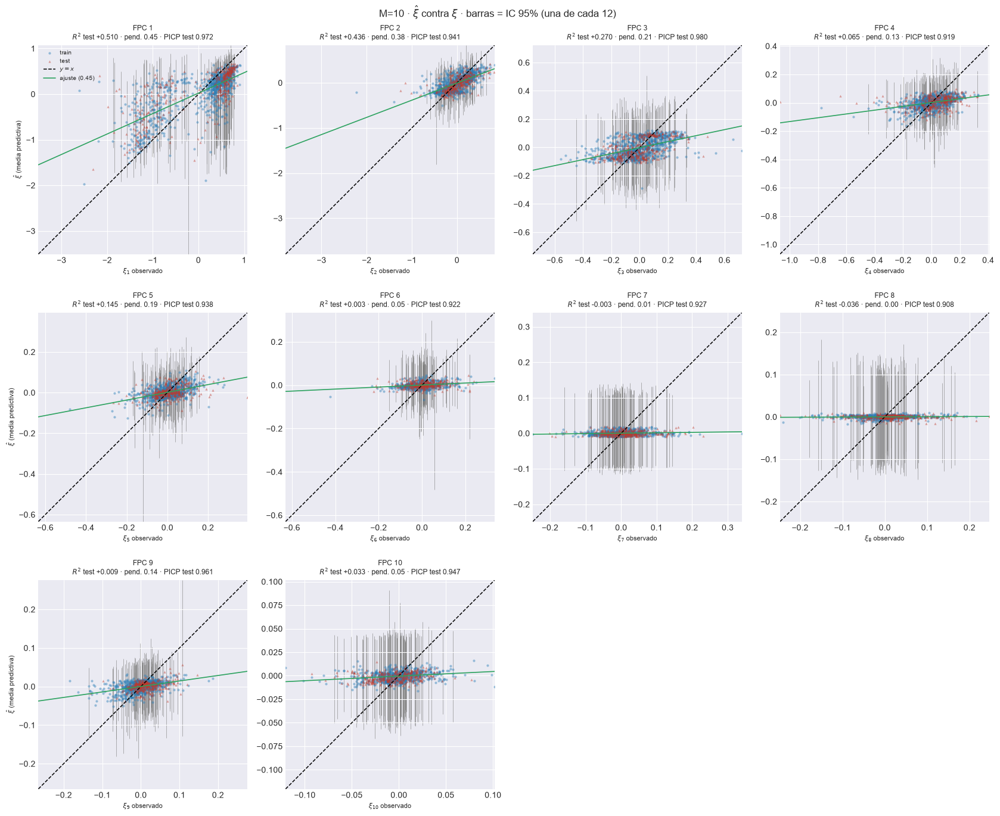

In [18]:
for M in M_OK:
    plot_scores_dispersion(EST[M], ORIG, DIS, M, CADA_BARRA,
                           save_path=EST[M]["paths"]["out_report"] / "94_scores_dispersion_vs_real.png")
    plt.show()